In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy as sp

In [2]:
df = pd.read_csv('data_source/amazon.csv')

In [3]:
df.columns

Index(['product_id', 'product_name', 'category', 'discounted_price',
       'actual_price', 'discount_percentage', 'rating', 'rating_count',
       'about_product', 'user_id', 'user_name', 'review_id', 'review_title',
       'review_content', 'img_link', 'product_link'],
      dtype='object')

In [4]:
df.head()

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹399,"₹1,099",64%,4.2,"24,269",High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,₹199,₹349,43%,4.0,"43,994","Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,₹199,"₹1,899",90%,3.9,"7,928",【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,₹329,₹699,53%,4.2,"94,363",The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,₹154,₹399,61%,4.2,"16,905",[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...","As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   product_id           1465 non-null   object
 1   product_name         1465 non-null   object
 2   category             1465 non-null   object
 3   discounted_price     1465 non-null   object
 4   actual_price         1465 non-null   object
 5   discount_percentage  1465 non-null   object
 6   rating               1465 non-null   object
 7   rating_count         1463 non-null   object
 8   about_product        1465 non-null   object
 9   user_id              1465 non-null   object
 10  user_name            1465 non-null   object
 11  review_id            1465 non-null   object
 12  review_title         1465 non-null   object
 13  review_content       1465 non-null   object
 14  img_link             1465 non-null   object
 15  product_link         1465 non-null   object
dtypes: obj

In [6]:
df.isnull().sum()


product_id             0
product_name           0
category               0
discounted_price       0
actual_price           0
discount_percentage    0
rating                 0
rating_count           2
about_product          0
user_id                0
user_name              0
review_id              0
review_title           0
review_content         0
img_link               0
product_link           0
dtype: int64

In [7]:
# keep original df untouched
df_clean = df.drop(columns=['img_link', 'product_link', 'review_id',
                              'user_id', 'user_name', 'review_title',
                              'review_content', 'about_product'])

In [8]:
# verify
print("Original:", df.shape)
print("Cleaned:", df_clean.shape)

Original: (1465, 16)
Cleaned: (1465, 8)


In [9]:
df_clean.head()

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹399,"₹1,099",64%,4.2,"24,269"
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,₹199,₹349,43%,4.0,"43,994"
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,₹199,"₹1,899",90%,3.9,"7,928"
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,₹329,₹699,53%,4.2,"94,363"
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,₹154,₹399,61%,4.2,"16,905"


In [10]:
df_clean['discounted_price'] = df_clean['discounted_price'].str.replace('₹', '').str.replace(',', '').astype(float)
df_clean['actual_price'] = df_clean['actual_price'].str.replace('₹', '').str.replace(',', '').astype(float)
df_clean['discount_percentage'] = df_clean['discount_percentage'].str.replace('%', '').astype(float)
df_clean['rating'] = pd.to_numeric(df_clean['rating'], errors='coerce')
df_clean['rating_count'] = df_clean['rating_count'].str.replace(',', '').astype(float)
df_clean['main_category'] = df_clean['category'].str.split('|').str[0]

In [11]:
df_clean['main_category'].value_counts()

main_category
Electronics              526
Computers&Accessories    453
Home&Kitchen             448
OfficeProducts            31
MusicalInstruments         2
HomeImprovement            2
Toys&Games                 1
Car&Motorbike              1
Health&PersonalCare        1
Name: count, dtype: int64

In [12]:
df_clean.describe()

,discounted_price,actual_price,discount_percentage,rating,rating_count
count,1465.000000,1465.000000,1465.000000,1464.000000,1463.000000
mean,3125.310874,5444.990635,47.691468,4.096585,18295.541353
std,6944.304394,10874.826864,21.635905,0.291674,42753.864952
min,39.000000,39.000000,0.000000,2.000000,2.000000
25%,325.000000,800.000000,32.000000,4.000000,1186.000000
50%,799.000000,1650.000000,50.000000,4.100000,5179.000000
75%,1999.000000,4295.000000,63.000000,4.300000,17336.500000
max,77990.000000,139900.000000,94.000000,5.000000,426973.000000


In [13]:
df_clean.isna().sum()

product_id             0
product_name           0
category               0
discounted_price       0
actual_price           0
discount_percentage    0
rating                 1
rating_count           2
main_category          0
dtype: int64

In [14]:
df_clean['rating'] = df_clean['rating'].fillna(df_clean['rating'].median())
df_clean['rating_count'] = df_clean['rating_count'].fillna(df_clean['rating_count'].median())

In [15]:
df_clean['savings'] = df_clean['actual_price'] - df_clean['discounted_price']

df_clean['discount_tier'] = pd.cut(df_clean['discount_percentage'],
                                    bins=[0, 20, 40, 60, 80, 100],
                                    labels=['0-20%', '21-40%', '41-60%', '61-80%', '81-100%'])

In [16]:
print(df_clean.shape)
print(df_clean.dtypes)
df_clean.head()

(1465, 11)
product_id               object
product_name             object
category                 object
discounted_price        float64
actual_price            float64
discount_percentage     float64
rating                  float64
rating_count            float64
main_category            object
savings                 float64
discount_tier          category
dtype: object


,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,main_category,savings,discount_tier
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,399.0,1099.0,64.0,4.2,24269.0,Computers&Accessories,700.0,61-80%
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,199.0,349.0,43.0,4.0,43994.0,Computers&Accessories,150.0,41-60%
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,199.0,1899.0,90.0,3.9,7928.0,Computers&Accessories,1700.0,81-100%
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,329.0,699.0,53.0,4.2,94363.0,Computers&Accessories,370.0,41-60%
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,154.0,399.0,61.0,4.2,16905.0,Computers&Accessories,245.0,61-80%


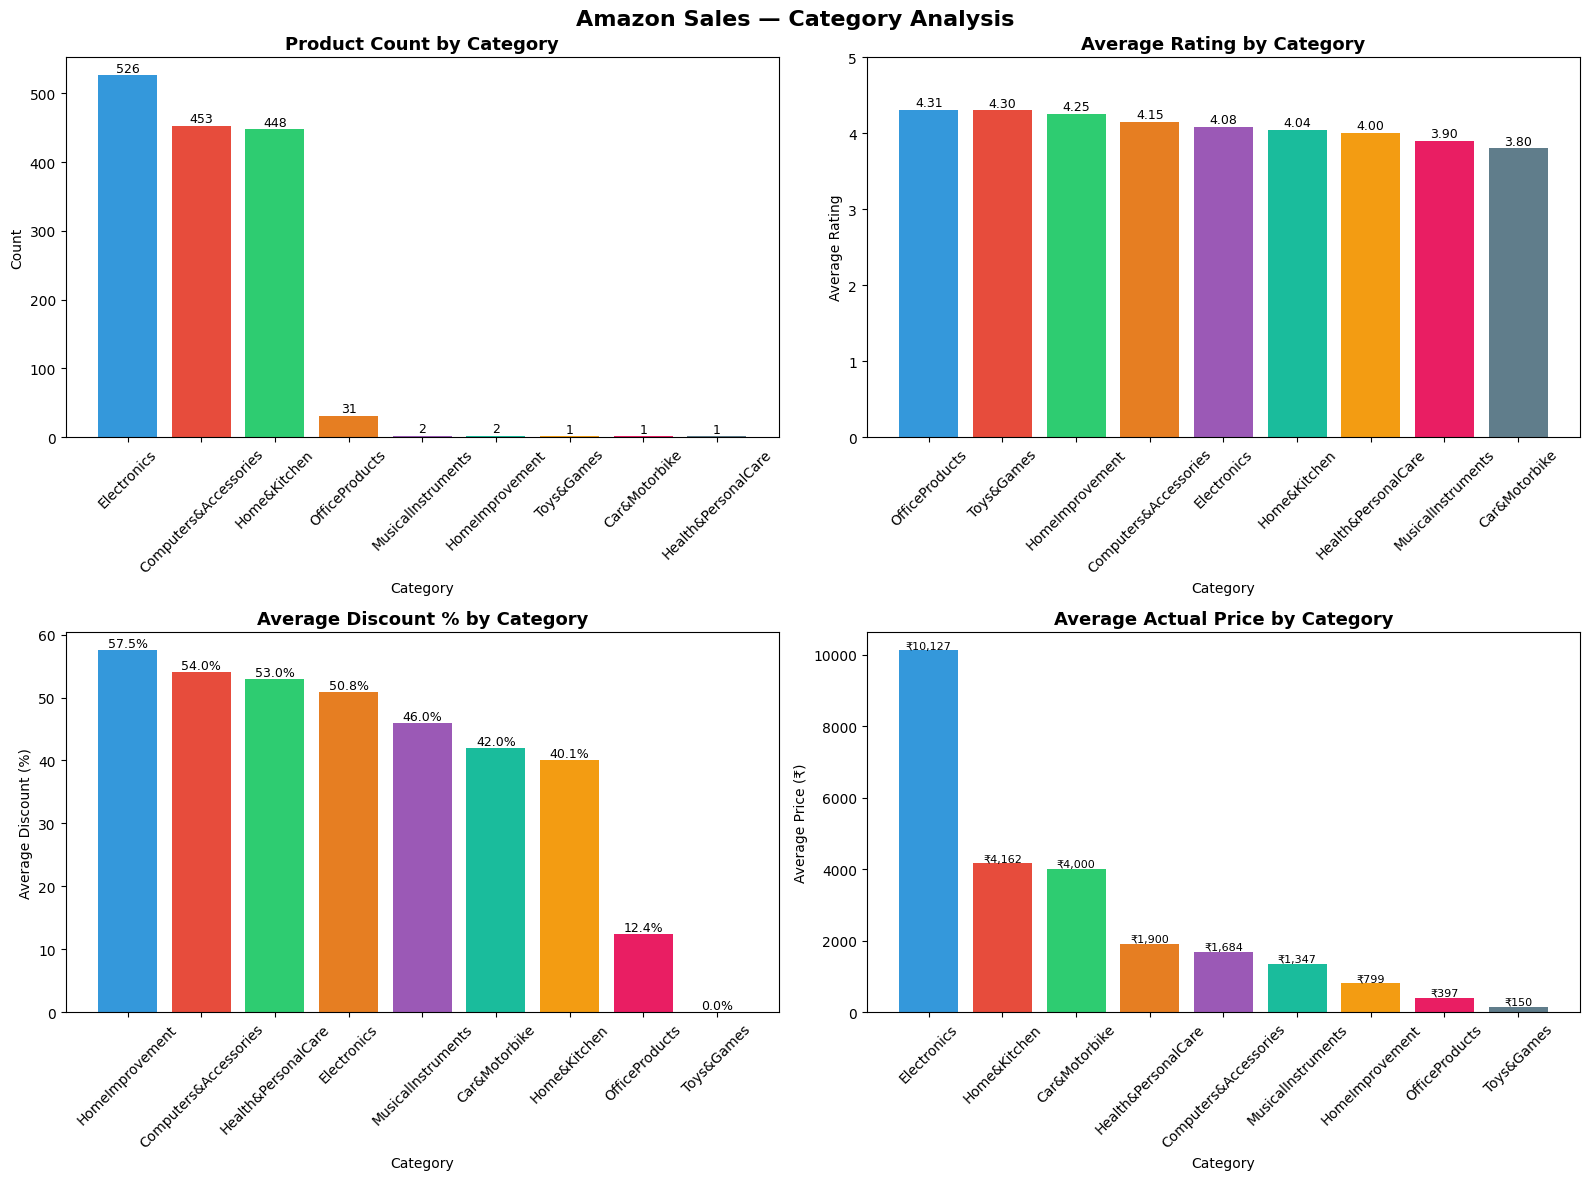

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

# color palette
colors = ['#3498db', '#e74c3c', '#2ecc71', '#e67e22',
          '#9b59b6', '#1abc9c', '#f39c12', '#e91e63', '#607d8b']

# ── 1. Product count by category ──────────────────────────────
data1 = df_clean['main_category'].value_counts()
bars = axes[0].bar(data1.index, data1.values, color=colors[:len(data1)])
axes[0].set_title('Product Count by Category', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)
for bar, val in zip(bars, data1.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 5,
                 str(val), ha='center', fontsize=9)

# ── 2. Average rating by category ─────────────────────────────
data2 = df_clean.groupby('main_category')['rating'].mean().sort_values(ascending=False)
bars = axes[1].bar(data2.index, data2.values, color=colors[:len(data2)])
axes[1].set_title('Average Rating by Category', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Category')
axes[1].set_ylabel('Average Rating')
axes[1].set_ylim(0, 5)
axes[1].tick_params(axis='x', rotation=45)
for bar, val in zip(bars, data2.values):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.05,
                 f'{val:.2f}', ha='center', fontsize=9)

# ── 3. Average discount by category ───────────────────────────
data3 = df_clean.groupby('main_category')['discount_percentage'].mean().sort_values(ascending=False)
bars = axes[2].bar(data3.index, data3.values, color=colors[:len(data3)])
axes[2].set_title('Average Discount % by Category', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Category')
axes[2].set_ylabel('Average Discount (%)')
axes[2].tick_params(axis='x', rotation=45)
for bar, val in zip(bars, data3.values):
    axes[2].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', fontsize=9)

# ── 4. Average actual price by category ───────────────────────
data4 = df_clean.groupby('main_category')['actual_price'].mean().sort_values(ascending=False)
bars = axes[3].bar(data4.index, data4.values, color=colors[:len(data4)])
axes[3].set_title('Average Actual Price by Category', fontsize=13, fontweight='bold')
axes[3].set_xlabel('Category')
axes[3].set_ylabel('Average Price (₹)')
axes[3].tick_params(axis='x', rotation=45)
for bar, val in zip(bars, data4.values):
    axes[3].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 50,
                 f'₹{val:,.0f}', ha='center', fontsize=8)

fig.suptitle('Amazon Sales — Category Analysis',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('visualizations/category_analysis.png', dpi=150)
plt.show()

/var/folders/3x/r8c2gxtj63bb36xdz4fz55xc0000gp/T/ipykernel_5217/2877118551.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='main_category', y='actual_price',


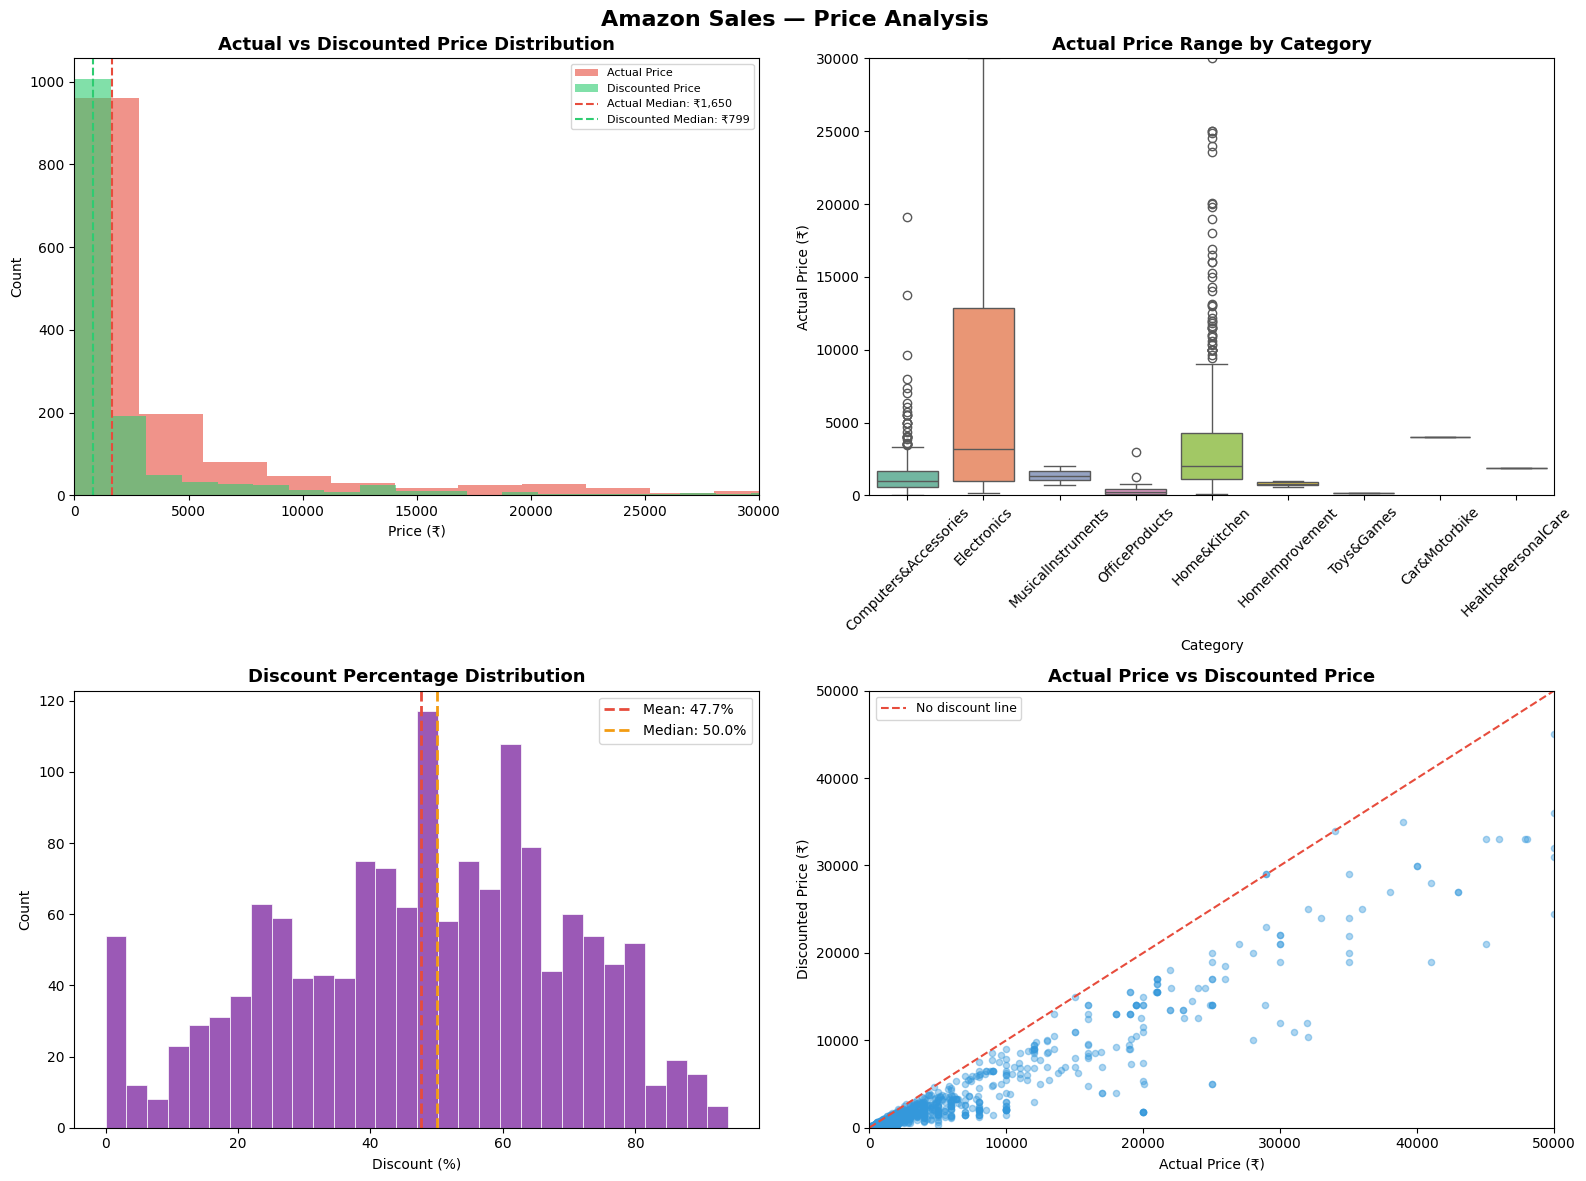

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

# ── 5. Discounted vs actual price distribution ─────────────────
axes[0].hist(df_clean['actual_price'], bins=50, alpha=0.6,
             color='#e74c3c', label='Actual Price')
axes[0].hist(df_clean['discounted_price'], bins=50, alpha=0.6,
             color='#2ecc71', label='Discounted Price')
axes[0].set_title('Actual vs Discounted Price Distribution',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Price (₹)')
axes[0].set_ylabel('Count')
axes[0].set_xlim(0, 30000)   # cap at 30k for readability
axes[0].legend()
axes[0].axvline(df_clean['actual_price'].median(), color='#e74c3c',
                linestyle='--', linewidth=1.5,
                label=f'Actual Median: ₹{df_clean["actual_price"].median():,.0f}')
axes[0].axvline(df_clean['discounted_price'].median(), color='#2ecc71',
                linestyle='--', linewidth=1.5,
                label=f'Discounted Median: ₹{df_clean["discounted_price"].median():,.0f}')
axes[0].legend(fontsize=8)

# ── 6. Price range by category (box plot) ─────────────────────
sns.boxplot(data=df_clean, x='main_category', y='actual_price',
            palette='Set2', ax=axes[1])
axes[1].set_title('Actual Price Range by Category',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Category')
axes[1].set_ylabel('Actual Price (₹)')
axes[1].set_ylim(0, 30000)   # cap outliers for readability
axes[1].tick_params(axis='x', rotation=45)

# ── 7. Discount percentage distribution ───────────────────────
axes[2].hist(df_clean['discount_percentage'], bins=30,
             color='#9b59b6', edgecolor='white', linewidth=0.5)
axes[2].axvline(df_clean['discount_percentage'].mean(), color='#e74c3c',
                linestyle='--', linewidth=2,
                label=f'Mean: {df_clean["discount_percentage"].mean():.1f}%')
axes[2].axvline(df_clean['discount_percentage'].median(), color='#f39c12',
                linestyle='--', linewidth=2,
                label=f'Median: {df_clean["discount_percentage"].median():.1f}%')
axes[2].set_title('Discount Percentage Distribution',
                  fontsize=13, fontweight='bold')
axes[2].set_xlabel('Discount (%)')
axes[2].set_ylabel('Count')
axes[2].legend()

# ── 8. Actual price vs discounted price scatter ────────────────
axes[3].scatter(df_clean['actual_price'], df_clean['discounted_price'],
                alpha=0.4, s=20, color='#3498db')

# add diagonal line — if no discount, points would be here
max_price = df_clean['actual_price'].max()
axes[3].plot([0, max_price], [0, max_price], color='#e74c3c',
             linestyle='--', linewidth=1.5, label='No discount line')

axes[3].set_title('Actual Price vs Discounted Price',
                  fontsize=13, fontweight='bold')
axes[3].set_xlabel('Actual Price (₹)')
axes[3].set_ylabel('Discounted Price (₹)')
axes[3].set_xlim(0, 50000)
axes[3].set_ylim(0, 50000)
axes[3].legend(fontsize=9)

fig.suptitle('Amazon Sales — Price Analysis',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('visualizations/price_analysis.png', dpi=150)
plt.show()

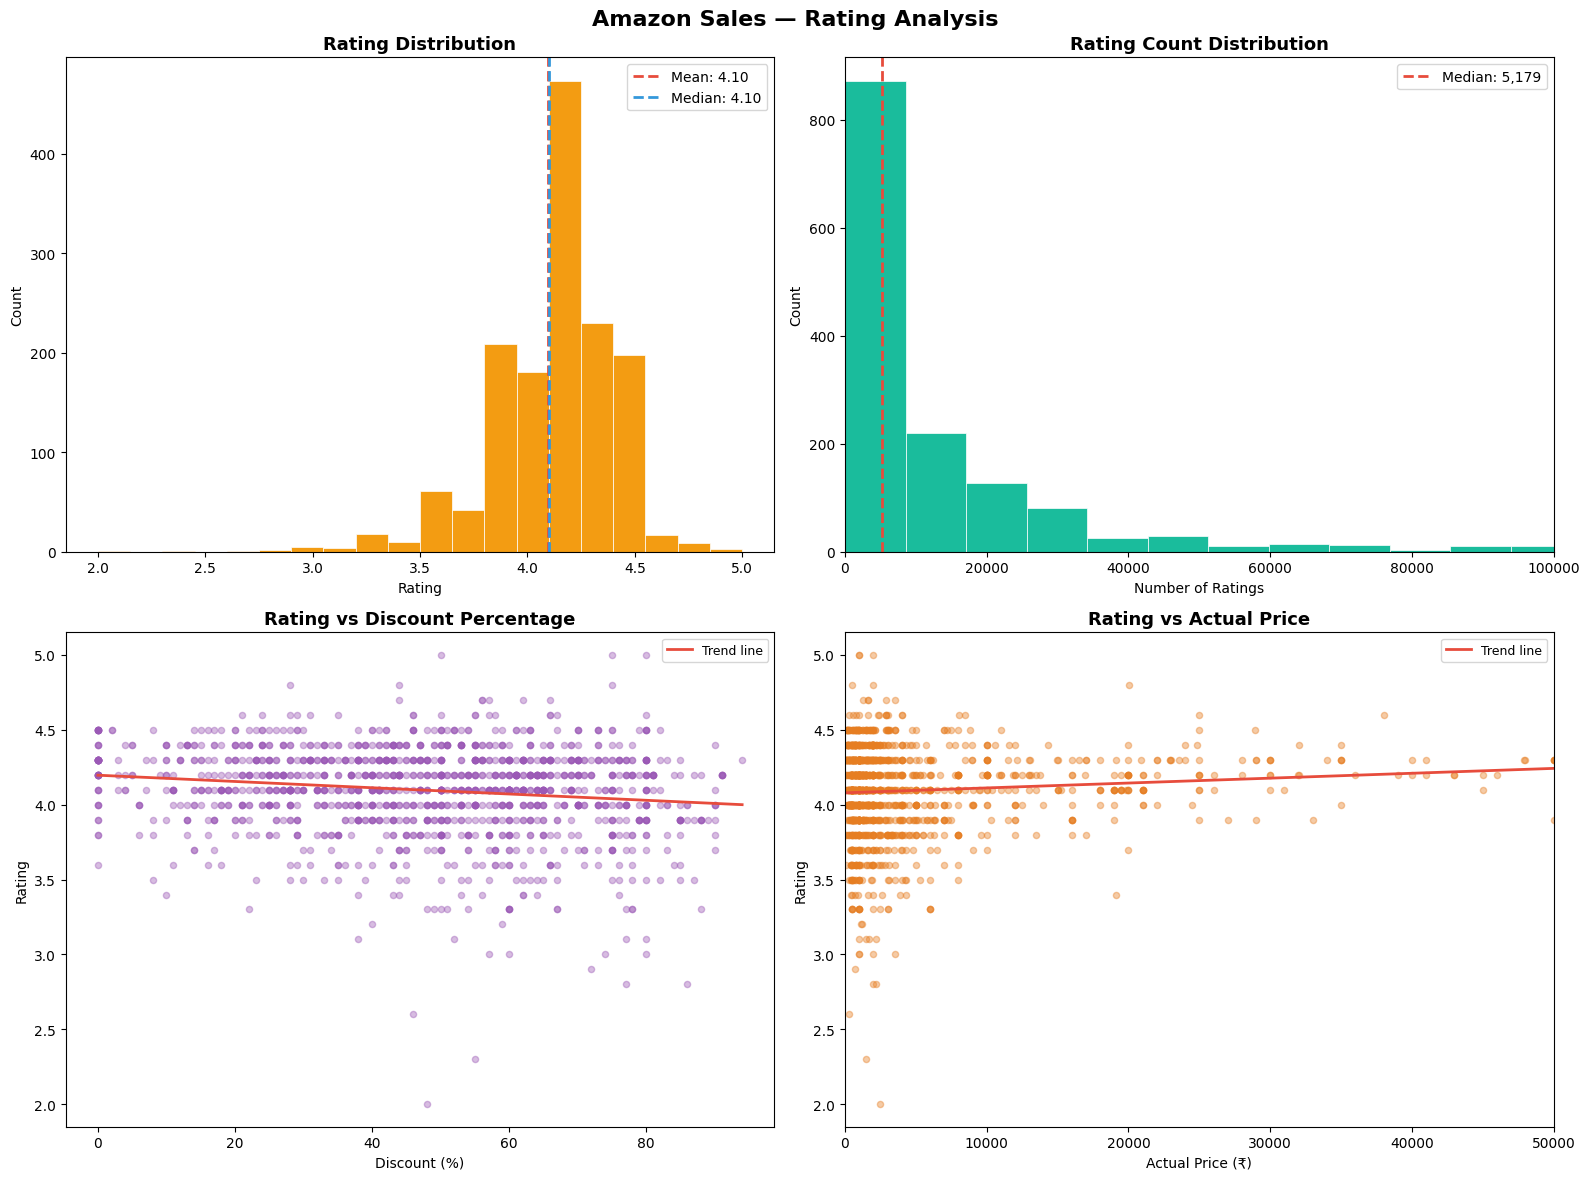

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

# ── 9. Rating distribution ─────────────────────────────────────
axes[0].hist(df_clean['rating'], bins=20,
             color='#f39c12', edgecolor='white', linewidth=0.5)
axes[0].axvline(df_clean['rating'].mean(), color='#e74c3c',
                linestyle='--', linewidth=2,
                label=f'Mean: {df_clean["rating"].mean():.2f}')
axes[0].axvline(df_clean['rating'].median(), color='#3498db',
                linestyle='--', linewidth=2,
                label=f'Median: {df_clean["rating"].median():.2f}')
axes[0].set_title('Rating Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Count')
axes[0].legend()

# ── 10. Rating count distribution ─────────────────────────────
axes[1].hist(df_clean['rating_count'], bins=50,
             color='#1abc9c', edgecolor='white', linewidth=0.5)
axes[1].axvline(df_clean['rating_count'].median(), color='#e74c3c',
                linestyle='--', linewidth=2,
                label=f'Median: {df_clean["rating_count"].median():,.0f}')
axes[1].set_title('Rating Count Distribution',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of Ratings')
axes[1].set_ylabel('Count')
axes[1].set_xlim(0, 100000)   # cap for readability
axes[1].legend()

# ── 11. Rating vs discount percentage scatter ──────────────────
axes[2].scatter(df_clean['discount_percentage'], df_clean['rating'],
                alpha=0.4, s=20, color='#9b59b6')

# trend line
z = np.polyfit(df_clean['discount_percentage'], df_clean['rating'], 1)
p = np.poly1d(z)
x_line = np.linspace(df_clean['discount_percentage'].min(),
                     df_clean['discount_percentage'].max(), 100)
axes[2].plot(x_line, p(x_line), color='#e74c3c',
             linewidth=2, label='Trend line')

axes[2].set_title('Rating vs Discount Percentage',
                  fontsize=13, fontweight='bold')
axes[2].set_xlabel('Discount (%)')
axes[2].set_ylabel('Rating')
axes[2].legend(fontsize=9)

# ── 12. Rating vs actual price scatter ────────────────────────
axes[3].scatter(df_clean['actual_price'], df_clean['rating'],
                alpha=0.4, s=20, color='#e67e22')

# trend line
z = np.polyfit(df_clean['actual_price'], df_clean['rating'], 1)
p = np.poly1d(z)
x_line = np.linspace(df_clean['actual_price'].min(),
                     df_clean['actual_price'].max(), 100)
axes[3].plot(x_line, p(x_line), color='#e74c3c',
             linewidth=2, label='Trend line')

axes[3].set_title('Rating vs Actual Price',
                  fontsize=13, fontweight='bold')
axes[3].set_xlabel('Actual Price (₹)')
axes[3].set_ylabel('Rating')
axes[3].set_xlim(0, 50000)
axes[3].legend(fontsize=9)

fig.suptitle('Amazon Sales — Rating Analysis',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('visualizations/rating_analysis.png', dpi=150)
plt.show()